# Klasifikasi Gambar Pemandangan Alam

## Setup

In [ ]:
!pip install tensorflowjs -q

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow versi : {tf.__version__}')
print(f'GPU tersedia     : {tf.config.list_physical_devices("GPU")}')

TensorFlow versi : 2.19.0
GPU tersedia     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Mount Google Drive & Konfigurasi Path

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!cp -r "/content/drive/MyDrive/data_deep_learning" "/content/data_deep_learning"

In [4]:
BASE_DIR  = '/content/data_deep_learning'
TRAIN_DIR = os.path.join(BASE_DIR, 'seg_train', 'seg_train')
TEST_DIR  = os.path.join(BASE_DIR, 'seg_test',  'seg_test')
PRED_DIR  = os.path.join(BASE_DIR, 'seg_pred',  'seg_pred')

IMG_SIZE    = (150, 150)
BATCH_SIZE  = 32
EPOCHS      = 30
NUM_CLASSES = 6
CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Validasi keberadaan direktori
for path, label in [(TRAIN_DIR, 'Train'), (TEST_DIR, 'Test'), (PRED_DIR, 'Pred')]:
    exists = os.path.isdir(path)
    status = 'OK' if exists else 'X  (periksa path!)'
    print(f'[{status}] {label:5s} -> {path}')

[OK] Train -> /content/data_deep_learning/seg_train/seg_train
[OK] Test  -> /content/data_deep_learning/seg_test/seg_test
[OK] Pred  -> /content/data_deep_learning/seg_pred/seg_pred


## Eksplorasi Dataset (EDA)

In [5]:
def hitung_gambar(direktori, label):
    total = 0
    print(f'\n{label}:')
    print(f'{"Kelas":<12} {"Jumlah":>8}')
    for kelas in sorted(os.listdir(direktori)):
        path_kelas = os.path.join(direktori, kelas)
        if os.path.isdir(path_kelas):
            n = len(os.listdir(path_kelas))
            print(f'{kelas:<12} {n:>8}')
            total += n
    print(f'{"TOTAL":<12} {total:>8}')
    return total

n_train = hitung_gambar(TRAIN_DIR, 'Training Set')
n_test  = hitung_gambar(TEST_DIR,  'Test Set')
print(f'\nTotal keseluruhan : {n_train + n_test:,} gambar')


Training Set:
Kelas          Jumlah
buildings        2191
forest           2271
glacier          2416
mountain         2512
sea              2274
street           2382
TOTAL           14046

Test Set:
Kelas          Jumlah
buildings         437
forest            478
glacier           553
mountain          525
sea               510
street            501
TOTAL            3004

Total keseluruhan : 17,050 gambar


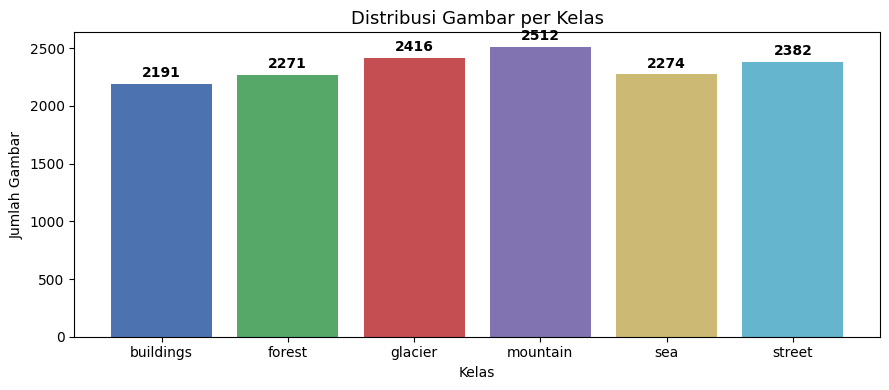

In [6]:
# Visualisasi distribusi kelas
kelas_list  = sorted([k for k in os.listdir(TRAIN_DIR)
                       if os.path.isdir(os.path.join(TRAIN_DIR, k))])
jumlah_list = [len(os.listdir(os.path.join(TRAIN_DIR, k))) for k in kelas_list]

COLORS = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974','#64B5CD']

plt.figure(figsize=(9, 4))
bars = plt.bar(kelas_list, jumlah_list, color=COLORS)
for bar, n in zip(bars, jumlah_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(n), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Distribusi Gambar per Kelas', fontsize=13)
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

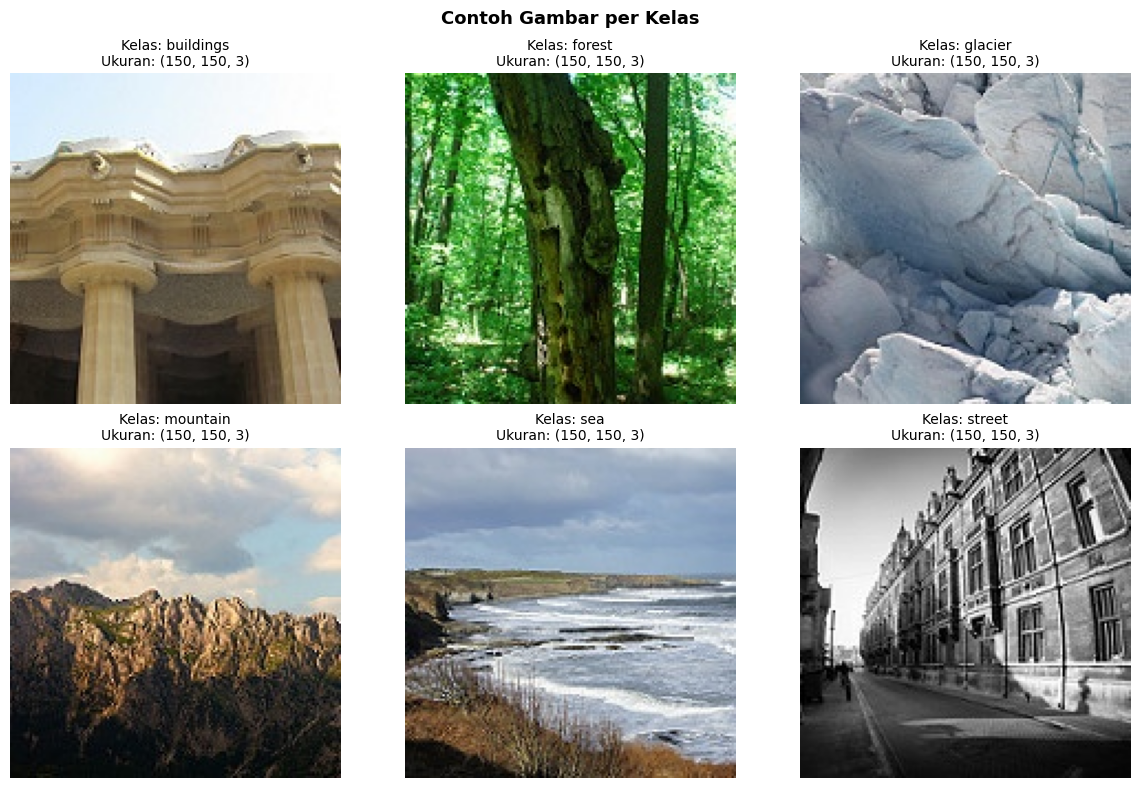

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, kelas in enumerate(kelas_list):
    path_kelas = os.path.join(TRAIN_DIR, kelas)
    gambar_path = os.path.join(path_kelas, os.listdir(path_kelas)[0])
    img = mpimg.imread(gambar_path)
    axes[i].imshow(img)
    axes[i].set_title(f'Kelas: {kelas}\nUkuran: {img.shape}', fontsize=10)
    axes[i].axis('off')
plt.suptitle('Contoh Gambar per Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Preprocessing & Augmentasi Data

In [8]:
# normalisasi + augmentasi + validation_split 10%
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'\nIndeks kelas  : {train_generator.class_indices}')
print(f'Training      : {train_generator.samples:,} gambar')
print(f'Validation    : {val_generator.samples:,} gambar')
print(f'Test          : {test_generator.samples:,} gambar')

Found 12643 images belonging to 6 classes.
Found 1403 images belonging to 6 classes.
Found 3004 images belonging to 6 classes.

Indeks kelas  : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Training      : 12,643 gambar
Validation    : 1,403 gambar
Test          : 3,004 gambar


## Arsitektur Model CNN

In [9]:
def buat_model(input_shape=(150, 150, 3), num_classes=6):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same',
               input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.30),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.30),
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name='Intel_Scene_CNN')

    return model


model = buat_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "Intel_Scene_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,206,566 (42.75 MB)

 Trainable params: 11,204,582 (42.74 MB)

 Non-trainable params: 1,984 (7.75 KB)

## Callback

In [10]:
os.makedirs('/content/checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='/content/checkpoints/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('Callback aktif:', [type(cb).__name__ for cb in callbacks])

Callback aktif: ['EarlyStopping', 'ModelCheckpoint', 'ReduceLROnPlateau']


## Training Model

In [11]:
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining selesai!')

Epoch 1/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.4877 - loss: 1.6146
Epoch 1: val_accuracy improved from None to 0.24376, saving model to /content/checkpoints/best_model.keras

Epoch 1: finished saving model to /content/checkpoints/best_model.keras
396/396 ━━━━━━━━━━━━━━━━━━━━ 142s 301ms/step - accuracy: 0.5388 - loss: 1.3528 - val_accuracy: 0.2438 - val_loss: 4.3215 - learning_rate: 0.0010
Epoch 2/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6329 - loss: 0.9801
Epoch 2: val_accuracy improved from 0.24376 to 0.48396, saving model to /content/checkpoints/best_model.keras

Epoch 2: finished saving model to /content/checkpoints/best_model.keras
396/396 ━━━━━━━━━━━━━━━━━━━━ 106s 254ms/step - accuracy: 0.6541 - loss: 0.9261 - val_accuracy: 0.4840 - val_loss: 1.7371 - learning_rate: 0.0010
Epoch 3/30
396/396 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.7071 - loss: 0.8100
Epoch 3: val_accuracy improved from 0.48396 to 0.60086, saving model to /content/ch

## Visualisasi Akurasi & Loss

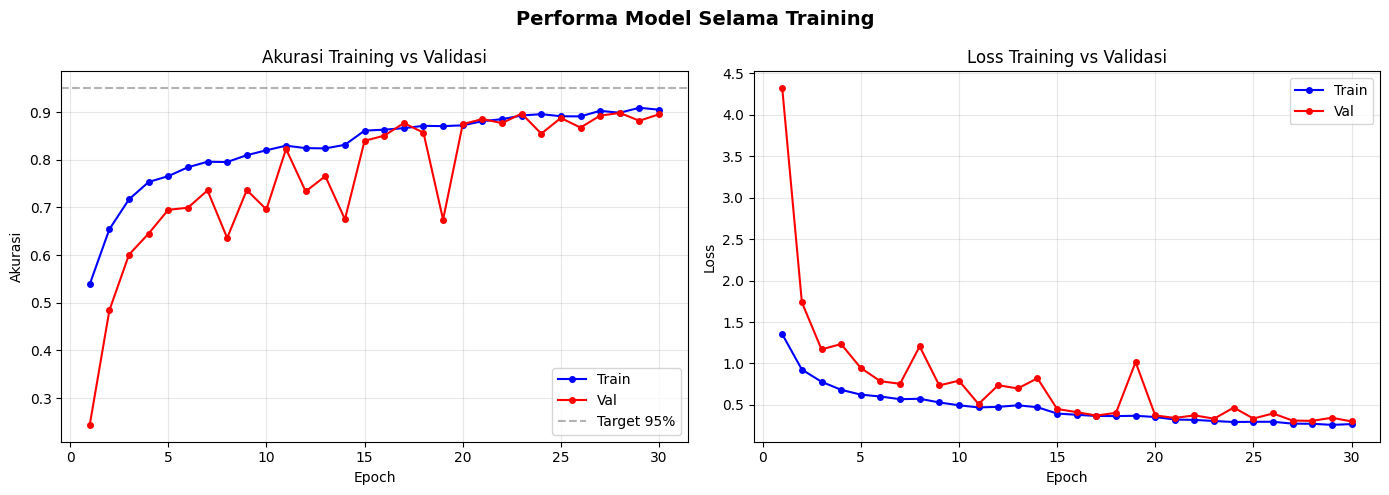


Akurasi validasi terbaik : 0.8981 (89.81%) pada epoch 28


In [12]:
def plot_history(history):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Akurasi
    ax1.plot(epochs, acc,     'b-o', label='Train', markersize=4)
    ax1.plot(epochs, val_acc, 'r-o', label='Val',   markersize=4)
    ax1.axhline(y=0.95, color='gray', linestyle='--', alpha=0.6, label='Target 95%')
    ax1.set_title('Akurasi Training vs Validasi', fontsize=12)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Akurasi')
    ax1.legend(); ax1.grid(alpha=0.3)

    # Plot Loss
    ax2.plot(epochs, loss,     'b-o', label='Train', markersize=4)
    ax2.plot(epochs, val_loss, 'r-o', label='Val',   markersize=4)
    ax2.set_title('Loss Training vs Validasi', fontsize=12)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle('Performa Model Selama Training', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

    best_val = max(val_acc)
    best_ep  = val_acc.index(best_val) + 1
    print(f'\nAkurasi validasi terbaik : {best_val:.4f} ({best_val*100:.2f}%) pada epoch {best_ep}')

plot_history(history)

## Evaluasi pada Test Set

In [13]:
# Evaluasi loss & akurasi keseluruhan
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.8795 - loss: 0.3378
Test Loss     : 0.3378
Test Accuracy : 0.8795 (87.95%)


In [14]:
# Prediksi semua gambar test untuk laporan klasifikasi
test_generator.reset()
y_pred_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step
              precision    recall  f1-score   support

   buildings       0.94      0.82      0.87       437
      forest       0.89      0.99      0.94       478
     glacier       0.85      0.83      0.84       553
    mountain       0.83      0.85      0.84       525
         sea       0.91      0.91      0.91       510
      street       0.88      0.88      0.88       501

    accuracy                           0.88      3004
   macro avg       0.88      0.88      0.88      3004
weighted avg       0.88      0.88      0.88      3004



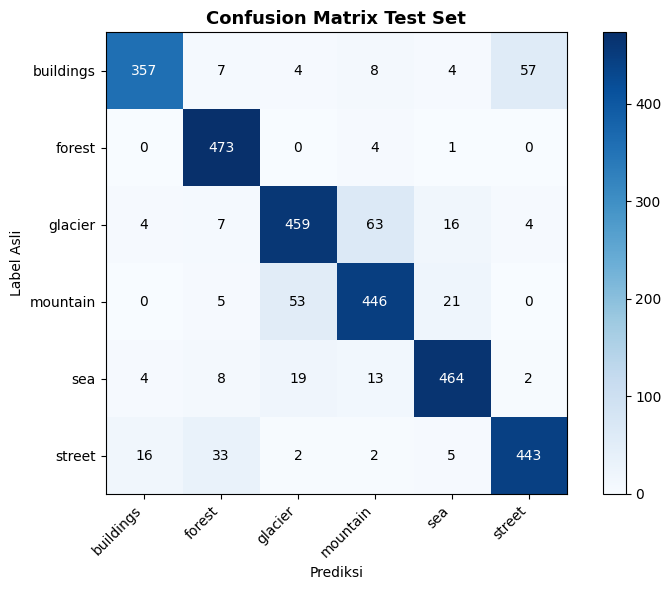

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
tick_marks = range(NUM_CLASSES)
ax.set_xticks(tick_marks); ax.set_yticks(tick_marks)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels(CLASS_NAMES)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black', fontsize=10)

ax.set_xlabel('Prediksi'); ax.set_ylabel('Label Asli')
ax.set_title('Confusion Matrix Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Menyimpan Model

### 10a. SavedModel

In [16]:
SAVED_MODEL_DIR = '/content/submission/saved_model'
os.makedirs(SAVED_MODEL_DIR, exist_ok=True)

# Export dalam format TF SavedModel
model.export(SAVED_MODEL_DIR)

print(f'SavedModel tersimpan di : {SAVED_MODEL_DIR}')
print(f'Isi folder              : {os.listdir(SAVED_MODEL_DIR)}')

Saved artifact at '/content/submission/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  131922878897744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878900624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878900816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878902736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878902160: TensorSpec(shape=(), dtype=tf.resource, name=None)
 

### 10b. TF-Lite

In [17]:
TFLITE_DIR = '/content/submission/tflite'
os.makedirs(TFLITE_DIR, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Simpan file model
tflite_path = os.path.join(TFLITE_DIR, 'model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

# Simpan file label
label_path = os.path.join(TFLITE_DIR, 'label.txt')
with open(label_path, 'w') as f:
    for kelas in CLASS_NAMES:
        f.write(kelas + '\n')

print(f'TF-Lite model tersimpan : {tflite_path}')
print(f'Label tersimpan         : {label_path}')
print(f'Ukuran model            : {os.path.getsize(tflite_path)/1024:.1f} KB')

Saved artifact at '/tmp/tmprwgd0g_k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  131922878897744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878900624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878901392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878900816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878902736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131922878902160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13192287890120

### 10c. TensorFlow.js

In [18]:
import tensorflowjs as tfjs

TFJS_DIR = '/content/submission/tfjs_model'
os.makedirs(TFJS_DIR, exist_ok=True)

tfjs.converters.save_keras_model(model, TFJS_DIR)

print(f'TFJS model tersimpan di : {TFJS_DIR}')
print(f'Isi folder              : {os.listdir(TFJS_DIR)}')

failed to lookup keras version from the file,
    this is likely a weight only file
TFJS model tersimpan di : /content/submission/tfjs_model
Isi folder              : ['group1-shard5of11.bin', 'group1-shard6of11.bin', 'group1-shard3of11.bin', 'group1-shard4of11.bin', 'group1-shard9of11.bin', 'group1-shard7of11.bin', 'group1-shard11of11.bin', 'group1-shard1of11.bin', 'group1-shard8of11.bin', 'group1-shard2of11.bin', 'group1-shard10of11.bin', 'model.json']


## Inferensi — Demo Prediksi (TF-Lite)

TF-Lite Interpreter siap
  Input shape  : [  1 150 150   3]
  Output shape : [1 6]


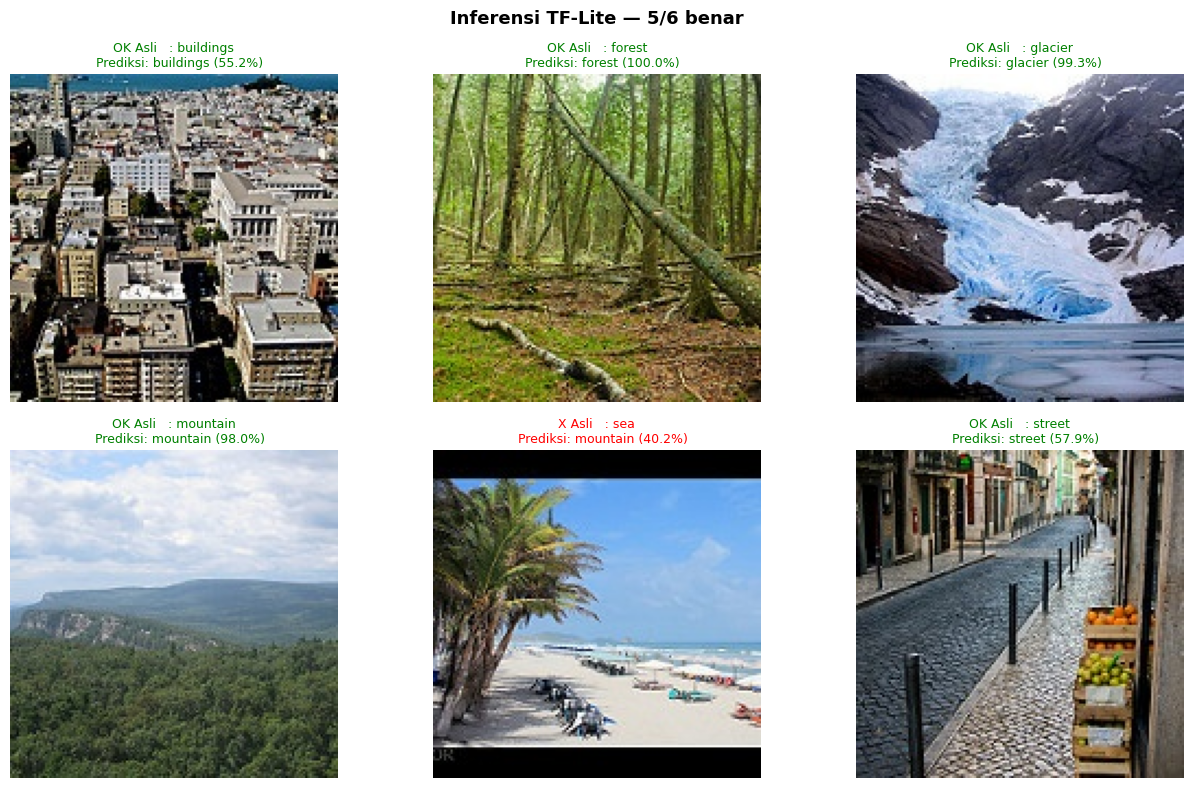


 Inferensi selesai — semua kelas berhasil diprediksi!


In [19]:
from PIL import Image

# Muat interpreter TF-Lite
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print('TF-Lite Interpreter siap')
print(f'  Input shape  : {input_details[0]["shape"]}')
print(f'  Output shape : {output_details[0]["shape"]}')

def predict_tflite(img_path):
    img       = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    interpreter.set_tensor(input_details[0]['index'], img_array)
    interpreter.invoke()
    probs = interpreter.get_tensor(output_details[0]['index'])[0]

    idx   = np.argmax(probs)
    return CLASS_NAMES[idx], probs[idx] * 100, probs

sampel = []
for kelas in CLASS_NAMES:
    path_kelas = os.path.join(TEST_DIR, kelas)
    if os.path.isdir(path_kelas):
        files = [f for f in os.listdir(path_kelas)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if files:
            sampel.append((os.path.join(path_kelas, files[0]), kelas))

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
benar = 0

for i, (img_path, label_asli) in enumerate(sampel):
    pred_kelas, conf, _ = predict_tflite(img_path)
    correct = pred_kelas == label_asli
    if correct: benar += 1

    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    warna = 'green' if correct else 'red'
    ikon  = 'OK' if correct else 'X'
    axes[i].set_title(
        f'{ikon} Asli   : {label_asli}\n'
        f'   Prediksi: {pred_kelas} ({conf:.1f}%)',
        fontsize=9, color=warna
    )
    axes[i].axis('off')

plt.suptitle(f'Inferensi TF-Lite — {benar}/{len(sampel)} benar',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('\n Inferensi selesai — semua kelas berhasil diprediksi!')